# Marriage and Education

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

from nsfg.paths import raw, interim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nsfg.utils import decorate, value_counts

from nsfg.utils import add_title, add_aibm_logo, add_subtext, savefig

In [3]:
# Make the figures smaller to save some screen real estate.
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = [6.75, 3.5]

# AIBM brand colors
aibm_light_gray = "#F3F4F3"
aibm_medium_gray = "#767676"
aibm_green = "#0B8569"
light_green = "#AAC9B8"
aibm_orange = "#C55300"
light_orange = "#F4A26B"
aibm_purple = "#9657A5"
light_purple = "#CFBCD0"
aibm_blue = "#4575D6"
light_blue = "#C9D3E8"

# additional colors from coolers.co
dark_gray = "#404040"
dark_purple = "#28112B"
dark_green = "#002500"
amber = "#F5BB00"
oxford_blue = "#000022"
bittersweet = "#FF6666"
crimson = "#D62839"

colors = [aibm_orange, aibm_green, aibm_blue, aibm_purple]
cycler = plt.cycler(color=colors)
plt.rc("axes", prop_cycle=cycler)

# tick and label colors
plt.rcParams["axes.edgecolor"] = aibm_medium_gray  # Spines (axis border)
plt.rcParams["xtick.color"] = aibm_medium_gray  # X-axis ticks
plt.rcParams["ytick.color"] = aibm_medium_gray  # Y-axis ticks
plt.rcParams["axes.labelcolor"] = aibm_medium_gray  # Axis labels

# remove all spines
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.bottom"] = False

# light gray horizontal grid lines
plt.rcParams["grid.color"] = aibm_light_gray
plt.rcParams["grid.linestyle"] = "-"  # Solid lines
plt.rcParams["grid.linewidth"] = 1  # Thin lines
plt.rcParams["axes.grid"] = True  # Enable grid
plt.rcParams["axes.grid.axis"] = "y"  # Apply only to horizontal lines

# Remove tick marks
plt.rcParams["xtick.major.size"] = 0
plt.rcParams["xtick.minor.size"] = 0
plt.rcParams["ytick.major.size"] = 0
plt.rcParams["ytick.minor.size"] = 0

# Use PT Sans as the default font
plt.rcParams["font.family"] = "PT Sans"

## Female respondents

Load the data cleaned in `clean_nsfg.ipynb`

In [4]:
resp = pd.read_parquet(interim("FemMarriageData.parquet"))
resp.shape

(75769, 53)

In [5]:
value_counts(resp["cycle"])

,counts
values,
3,7969
4,8450
5,10847
6,7643
7,12279
8,5601
9,5699
10,5554
11,6141


In [6]:
evrmarry = resp["evrmarry"]
value_counts(evrmarry)

,counts
values,
False,36608
True,39161


In [7]:
value_counts(resp["fmarital"])

,counts
values,
1.0,29135
2.0,505
3.0,6452
4.0,3072
5.0,36605


In [8]:
pd.crosstab(resp["fmarital"], resp["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
fmarital,,,,,,,,,,
1.0,3551,4031,5291,3080,3971,1711,1699,1828,1913,2060
2.0,79,68,93,51,57,25,23,44,40,25
3.0,587,802,1008,686,1009,465,471,509,550,365
4.0,434,389,452,309,497,251,208,201,219,112
5.0,3318,3160,4003,3517,6745,3149,3298,2972,3419,3024


In [9]:
resp["currmarr"] = resp["fmarital"] == 1
value_counts(resp["currmarr"])

,counts
values,
False,46634
True,29135


In [10]:
resp.groupby("birth_index")["currmarr"].mean()

birth_index
30     0.667692
40     0.657705
50     0.618851
60     0.439692
70     0.406329
80     0.305578
90     0.119894
100    0.010276
Name: currmarr, dtype: float64

In the 2000s cohorts, the last age where we have a decent sample is 23.

In [11]:
subset = resp.query("birth_index==100")
value_counts(subset["ager"]).tail()

,counts
values,
19.0,176
20.0,127
21.0,113
22.0,108
23.0,32


In the 1990s cohorts, the last age where we have a decent sample is 33.

In [12]:
subset = resp.query("birth_index==90")
value_counts(subset["ager"]).tail()

,counts
values,
29.0,211
30.0,206
31.0,198
32.0,207
33.0,67


In the 1980s cohorts, the last age where we have a decent sample is 43.

In [13]:
subset = resp.query("birth_index==80")
value_counts(subset["ager"]).tail()

,counts
values,
39.0,200
40.0,178
41.0,181
42.0,131
43.0,54


In [14]:
def add_married_column(resp, age):
    """Add a column indicating what fraction were married by a given age."""
    
    # Of all people interviewed >= age, how many had been married <= age
    col = f"married{age}"
    resp[col] = np.nan

    # if the respondent is not married, mark them unmarried for now
    unmarried = ~resp["evrmarry"]
    resp.loc[unmarried, col] = 0

    # if they have been married and they were married before age, mark them married
    married = resp["evrmarry"] & (resp["agemarry"] <= age)
    resp.loc[married, col] = 1

    # if they have been married, but not until after age, mark them unmarried
    married = resp["evrmarry"] & (resp["agemarry"] > age)
    resp.loc[married, col] = 0

    # if they were interviewed before age, we don't know yet, so mark them nan
    too_young = resp["ager"] < age
    resp.loc[too_young, col] = np.nan

    # if they have been married, but we don't know when, mark them nan
    missing = resp["evrmarry"] & resp["agemarry"].isna()
    resp.loc[missing, col] = np.nan

In [15]:
add_married_column(resp, 23)
value_counts(resp["married23"])

,counts
values,
0.0,35735
1.0,20426
NaN,19608


In [16]:
add_married_column(resp, 33)
value_counts(resp["married33"])

,counts
values,
0.0,7752
1.0,21737
NaN,46280


In [17]:
add_married_column(resp, 43)
value_counts(resp["married43"])

,counts
values,
0.0,1186
1.0,5030
NaN,69553


## Percent married by education level

`anycoll` is a recode I computed, intended to indicate whether a participant attended college, regardless of whether they got a degree.

```
1982    df['anycoll'] = df['educat'] >= 13
1988    df['anycoll'] = df['educat'] >= 13
1995    df["anycoll"] = df["hieduc"] >= 10
2002    df["anycoll"] = df["hieduc"] >= 10
2010    df["anycoll"] = df["hieduc"] >= 10
2013    df["anycoll"] = df["hieduc"] >= 10
2015    df["anycoll"] = df["hieduc"] >= 10
2017    df["anycoll"] = df["hieduc"] >= 10
2019    df["anycoll"] = df["hieduc"] >= 10
2023    df["anycoll"] = df["hieduc"] >= 5
```

In [18]:
resp.groupby("birth_index")["anycoll"].mean()

birth_index
30     0.286154
40     0.422672
50     0.466936
60     0.457656
70     0.532676
80     0.567669
90     0.405120
100    0.166277
Name: anycoll, dtype: float64

`bdegree` is a recode I computed, intended to indicate whether a participant has a bachelor's degree. For the first two cycles, we don't know for sure

```
1982    df['bdegree'] = df['educat'] >= 16
1988    df['bdegree'] = df['educat'] >= 16
1995    df["bdegree"] = df["hidegree"] >= 3
2002    df["bdegree"] = df["hieduc"] >= 12
2010    df["bdegree"] = df["hieduc"] >= 12
2013    df["bdegree"] = df["hieduc"] >= 12
2015    df["bdegree"] = df["hieduc"] >= 12
2017    df["bdegree"] = df["hieduc"] >= 12
2019    df["bdegree"] = df["hieduc"] >= 12
2023    df["bdegree"] = df["hieduc"] >= 8
```

In [19]:
resp.groupby("birth_index")["bdegree"].mean()

birth_index
30     0.126154
40     0.199279
50     0.211081
60     0.189116
70     0.267427
80     0.257150
90     0.142271
100    0.025689
Name: bdegree, dtype: float64

## Marriage Tables

In [20]:
from collections import defaultdict
from nsfg.utils import estimate_proportion

def make_table(resp, column, weight_col='finalwgt'):
    """Make a table with birth_index down the rows and bdegree on the columns."""
    data = defaultdict(dict)
    columns = ["p", "low", "high"]
    subset = resp.dropna(subset=[column, weight_col, 'birth_index', 'bdegree'])

    # put the results in a dictionary
    for (cohort, degree), group in subset.groupby(["birth_index", "bdegree"]):
        series = group[column]
        weight = group[weight_col] / group[weight_col].mean()
        row = estimate_proportion(series, weight, confidence_level=0.84)
        data[degree][cohort + 1900] = row

    # arrange the results in a DataFrame
    frames = {}
    for degree, results in data.items():
        df = pd.DataFrame.from_dict(results, orient="index", columns=columns)
        frames[degree] = df

    table = pd.concat(frames, axis=1)
    return table * 100

In [21]:
def plot_frame(df, **options):
    """Plot an estimated series with CI"""
    plt.fill_between(df.index, df['low'], df['high'], alpha=0.2)
    plt.plot(df['p'], **options)

def plot_table(table):
    """Plot a table with columns False and True."""
    plot_frame(table[False], label='No degree')
    plot_frame(table[True], label='Degree')

The weights are on different scales in different cycles, so we need to group by cycle and normalize so the mean in each cycle is 1.

In [22]:
from nsfg.utils import normalize_weights_by_cycle

normalized = normalize_weights_by_cycle(resp)
normalized['finalwgt'].describe()

count    75769.000000
mean         1.000000
std          0.940320
min          0.008169
25%          0.398990
50%          0.774474
75%          1.257050
max         32.513406
Name: finalwgt, dtype: float64

In [23]:
column = 'married23'
table23 = make_table(normalized, column)
table23

False                            True                       
              p        low       high          p        low       high
1930  78.351369  73.413653  82.589518  53.852304  39.929925  67.198618
1940  76.900280  75.469068  78.272032  47.648937  44.588781  50.726848
1950  66.504279  65.608841  67.387992  33.059434  31.418049  34.743131
1960  50.421728  49.360701  51.482376  22.233974  20.826016  23.708615
1970  39.572938  38.561791  40.593080  16.850530  15.786698  17.970753
1980  29.733257  28.666169  30.822903  14.181135  13.119278  15.313789
1990  21.273187  19.700453  22.935615   8.722043   7.339408  10.336092
2000  27.792538  12.935017  49.929126   0.000000   0.000000  16.668506

In [24]:
table33 = make_table(normalized, 'married33')

In [25]:
table43 = make_table(normalized, 'married43')

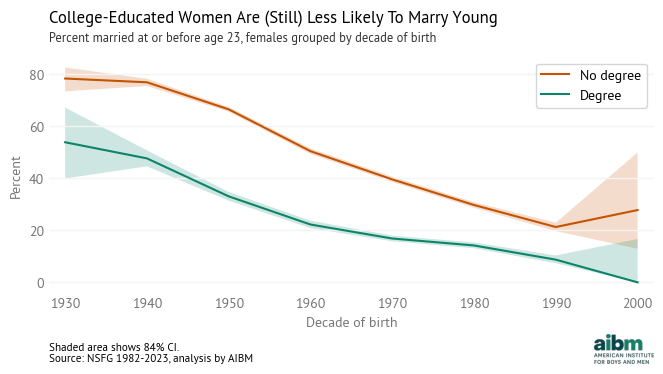

In [26]:
plot_table(table23)

title = "College-Educated Women Are (Still) Less Likely To Marry Young"
subtitle = "Percent married at or before age 23, females grouped by decade of birth"
add_title(title, subtitle)

subtext = """Shaded area shows 84% CI.
Source: NSFG 1982-2023, analysis by AIBM"""
add_subtext(subtext)

xlim = [1928, 2002]
decorate(xlabel="Decade of birth", ylabel="Percent", xlim=xlim)
inset = add_aibm_logo()
savefig("nsfg_marriage", 1, [inset])

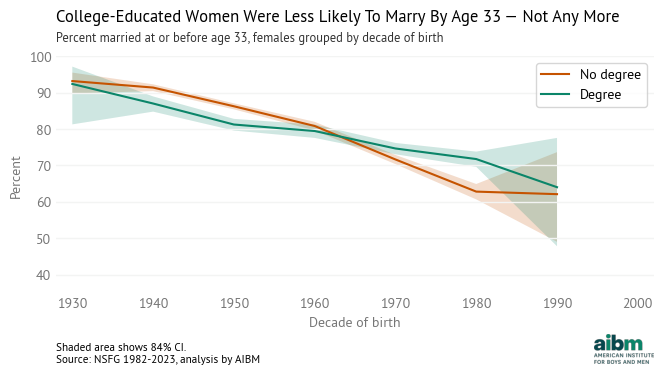

In [27]:
plot_table(table33)

title = "College-Educated Women Were Less Likely To Marry By Age 33 — Not Any More"
subtitle = "Percent married at or before age 33, females grouped by decade of birth"
add_title(title, subtitle)

add_subtext(subtext)

ylim = [35, 100]
decorate(xlabel="Decade of birth", ylabel="Percent", xlim=xlim, ylim=ylim)
inset = add_aibm_logo()
savefig("nsfg_marriage", 3, [inset])

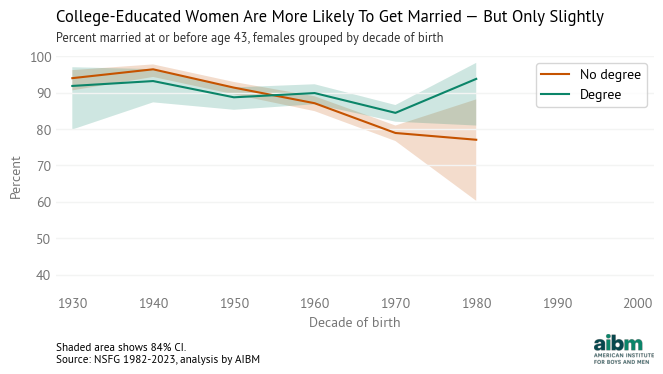

In [28]:
plot_table(table43)

title = "College-Educated Women Are More Likely To Get Married — But Only Slightly"
subtitle = "Percent married at or before age 43, females grouped by decade of birth"
add_title(title, subtitle)

add_subtext(subtext)

decorate(xlabel="Decade of birth", ylabel="Percent", xlim=xlim, ylim=ylim)
inset = add_aibm_logo()
savefig("nsfg_marriage", 5, [inset])

## Male respondents

Load the data cleaned in `clean_nsfg.ipynb`

`anycoll` is a recode I computed, intended to indicate whether a participant attended college, regardless of whether they got a degree.

```
2002    df["anycoll"] = df["hieduc"] >= 10
2010    df["anycoll"] = df["hieduc"] >= 10
2013    df["anycoll"] = df["hieduc"] >= 10
2015    df["anycoll"] = df["hieduc"] >= 10
2017    df["anycoll"] = df["hieduc"] >= 10
2019    df["anycoll"] = df["hieduc"] >= 10
2023    df["anycoll"] = df["hieduc"] >= 5
```

Encoding in 2023

```
HIEDUC: Distribution Value n
Less than high school completion 1 623
12th grade, no diploma 2 169
GED or equivalent 3 153
High school graduate 4 807
Some college, no degree 5 956
Associate degree: occup, tech, or voc 6 353
Associate degree: academic 7 282
Bachelor's degree 8 1267
Master's degree 9 752
Professional degree 10 135
Doctoral degree 11 89
5586
```

In [29]:
resp2 = pd.read_parquet(interim("MaleMarriageData.parquet"))
resp2.shape

(38769, 44)

In [30]:
evrmarry = resp2["evrmarry"]
value_counts(evrmarry)

,counts
values,
False,24634
True,14135


In the 2000s cohorts, the last age where we have a decent sample is 23.

In [31]:
subset = resp2.query("birth_index==100")
value_counts(subset["ager"]).tail()

,counts
values,
19.5,166
20.5,76
21.5,83
22.5,85
23.5,39


In the 1990s cohorts, the last age where we have a decent sample is 33.

In [32]:
subset = resp2.query("birth_index==90")
value_counts(subset["ager"]).tail()

,counts
values,
29.5,131
30.5,130
31.5,150
32.5,147
33.5,40


In the 1980s cohorts, the last age where we have a decent sample is 43.

In [33]:
subset = resp2.query("birth_index==80")
value_counts(subset["ager"]).tail()

,counts
values,
39.5,157
40.5,131
41.5,135
42.5,108
43.5,35


In [34]:
add_married_column(resp2, 23)
value_counts(resp2["married23"])

,counts
values,
0.0,23083
1.0,3962
NaN,11724


In [35]:
add_married_column(resp2, 33)
value_counts(resp2["married33"])

,counts
values,
0.0,6342
1.0,8272
NaN,24155


In [36]:
add_married_column(resp2, 43)
value_counts(resp2["married43"])

,counts
values,
0.0,1055
1.0,2607
NaN,35107


Again, we have to normalize the sampling weights in each cycle

In [37]:
normalized2 = normalize_weights_by_cycle(resp2)
normalized2['finalwgt'].describe()

count    38769.000000
mean         1.000000
std          1.071450
min          0.006480
25%          0.368552
50%          0.642911
75%          1.188582
max          8.789769
Name: finalwgt, dtype: float64

## Percent married by education level

In [38]:
resp2.groupby("birth_index")["anycoll"].mean()

birth_index
50     0.509317
60     0.511622
70     0.567716
80     0.518967
90     0.334536
100    0.121939
Name: anycoll, dtype: float64

In [39]:
resp2.groupby("birth_index")["bdegree"].mean()

birth_index
50     0.282609
60     0.265277
70     0.291851
80     0.227989
90     0.104878
100    0.017630
Name: bdegree, dtype: float64

In [40]:
resp2.groupby("birth_index")["evrmarry"].mean()

birth_index
50     0.695652
60     0.697819
70     0.611258
80     0.313087
90     0.078631
100    0.005387
Name: evrmarry, dtype: float64

In [41]:
table23 = make_table(normalized2, 'married23')

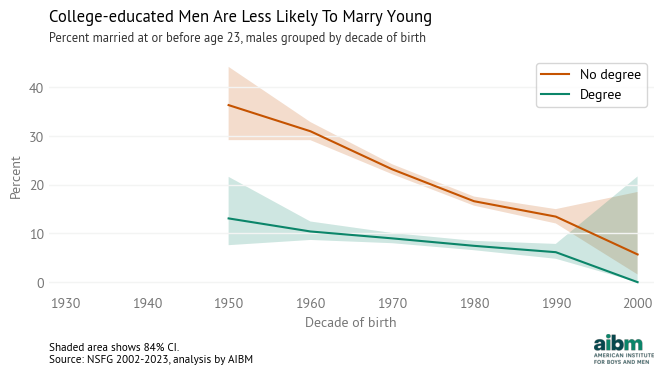

In [42]:
plot_table(table23)

title = "College-educated Men Are Less Likely To Marry Young"
subtitle = "Percent married at or before age 23, males grouped by decade of birth"
add_title(title, subtitle)

subtext = """Shaded area shows 84% CI.
Source: NSFG 2002-2023, analysis by AIBM"""
add_subtext(subtext)

xlim = [1928, 2002]
decorate(xlabel="Decade of birth", ylabel="Percent", xlim=xlim)
inset = add_aibm_logo()
savefig("nsfg_marriage", 2, [inset])

In [43]:
table33 = make_table(normalized2, 'married33')

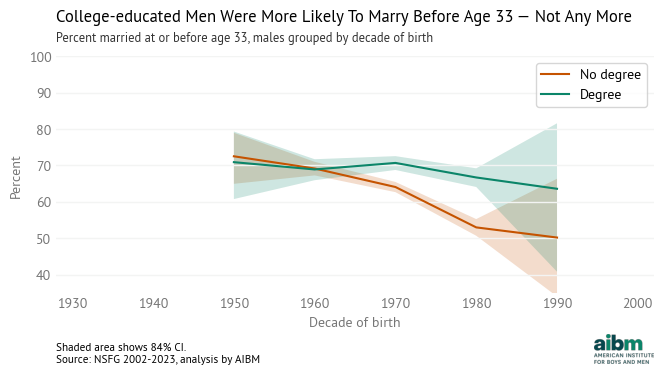

In [44]:
plot_table(table33)

title = "College-educated Men Were More Likely To Marry Before Age 33 — Not Any More"
subtitle = "Percent married at or before age 33, males grouped by decade of birth"
add_title(title, subtitle)

add_subtext(subtext)

ylim = [35, 100]
decorate(xlabel="Decade of birth", ylabel="Percent", xlim=xlim, ylim=ylim)
inset = add_aibm_logo()
savefig("nsfg_marriage", 4, [inset])

In [45]:
table43 = make_table(normalized2, 'married43')

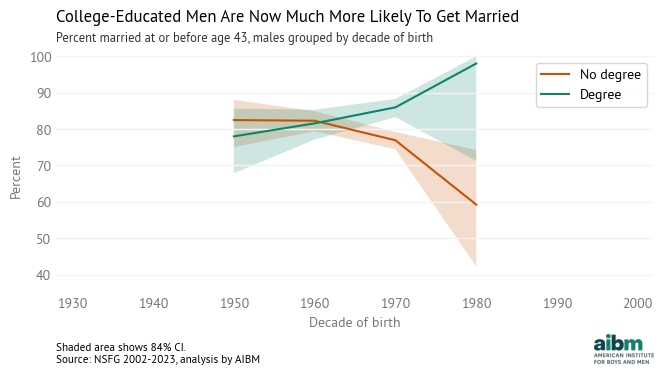

In [46]:
plot_table(table43)

title = "College-Educated Men Are Now Much More Likely To Get Married"
subtitle = "Percent married at or before age 43, males grouped by decade of birth"
add_title(title, subtitle)

add_subtext(subtext)

decorate(xlabel="Decade of birth", ylabel="Percent", xlim=xlim, ylim=ylim)
inset = add_aibm_logo()
savefig("nsfg_marriage", 6, [inset])